------------------------------------------------------------------
Data Elements

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 

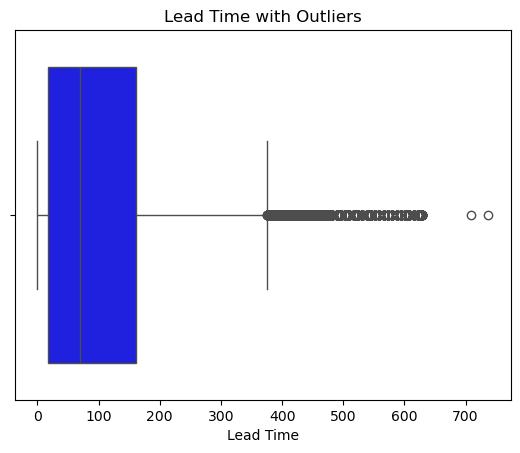

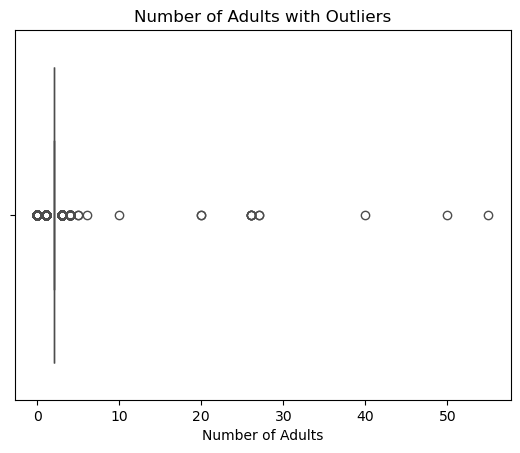

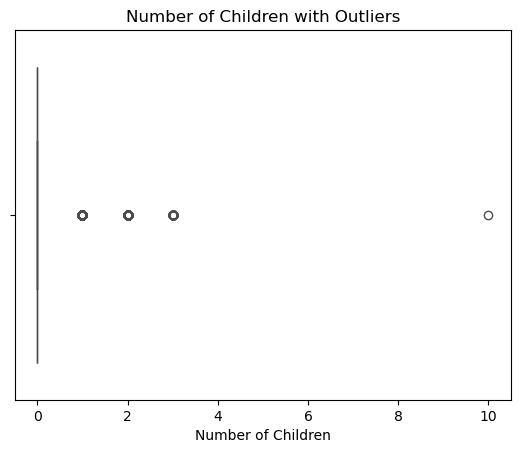

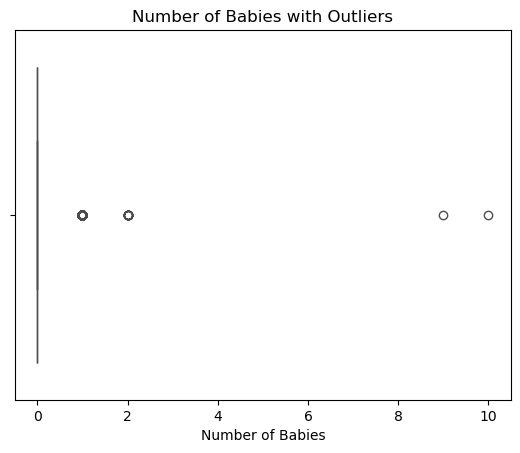

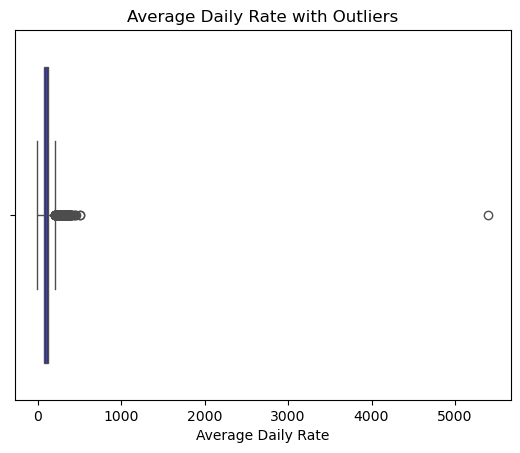

------------------------------------------------------------------

Hotel Category



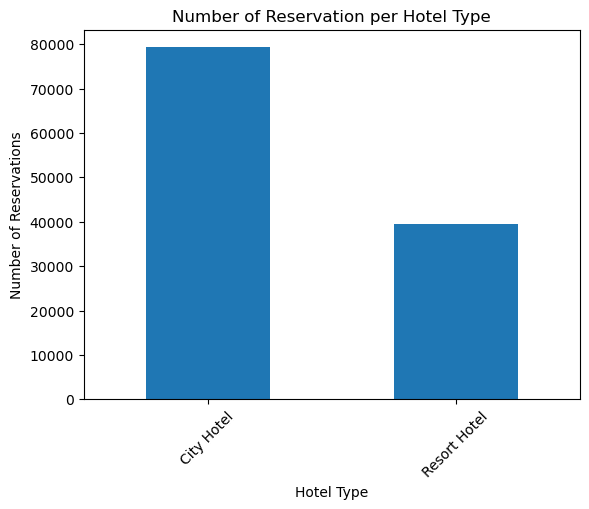

Cancelled



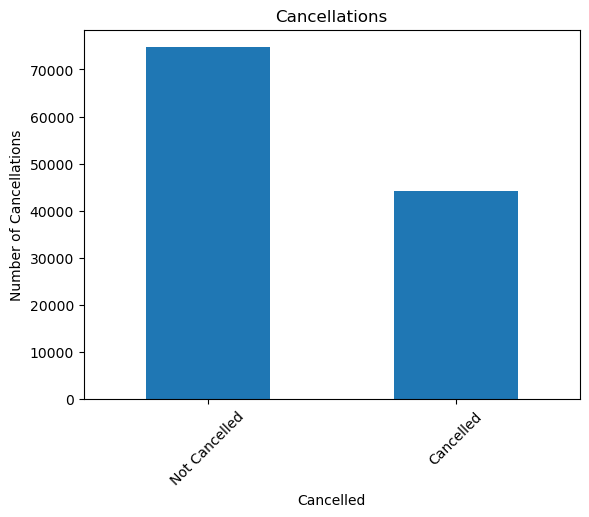

------------------------------------------------------------------

Cancellations by Hotel Type



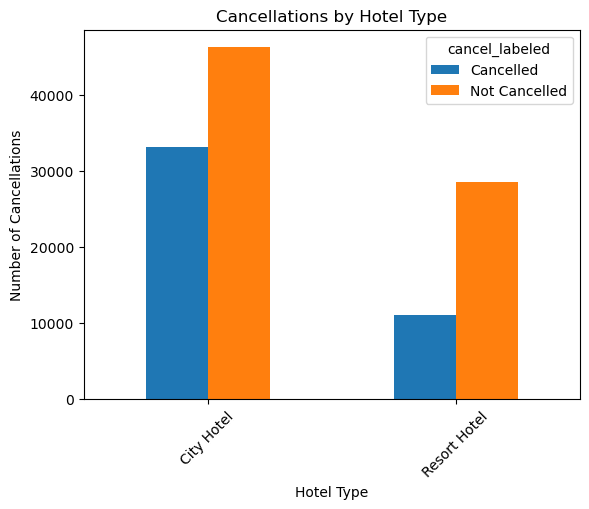

------------------------------------------------------------------

The correlation between lead_time and is_canceled: 0.2920
This indicated a small positive correlation.
------------------------------------------------------------------

The correlation between adr and is_canceled: 0.0473
This indicated a very small positive correlation.
------------------------------------------------------------------

The correlation between booking_changes and is_canceled: -0.1447
This indicated a small negative correlation.
------------------------------------------------------------------

The correlation between total_of_special_requests and is_canceled: -0.2356
This indicated a small negative correlation.
------------------------------------------------------------------

Cancellation Rates by Market Segment
  market_segment  total_bookings  total_canceled  cancellation_rate
0       Aviation             237              52          21.940928
1  Complementary             734              90    

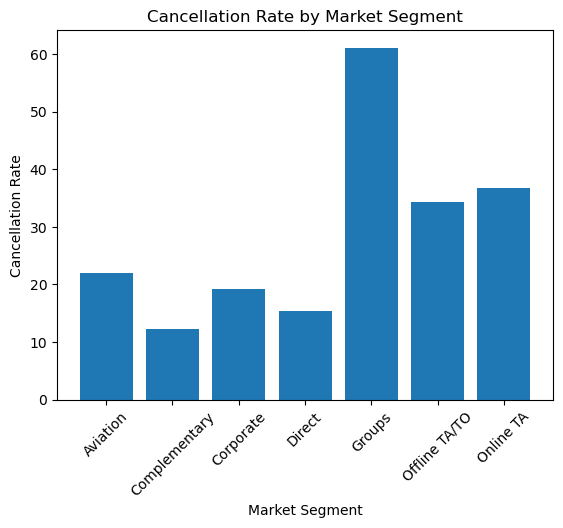

------------------------------------------------------------------

Cancellation Rates by Deposit Type
  deposit_type  total_bookings  total_canceled  cancellation_rate
0   No Deposit          104163           29637          28.452522
1   Non Refund           14572           14479          99.361790
2   Refundable             162              36          22.222222


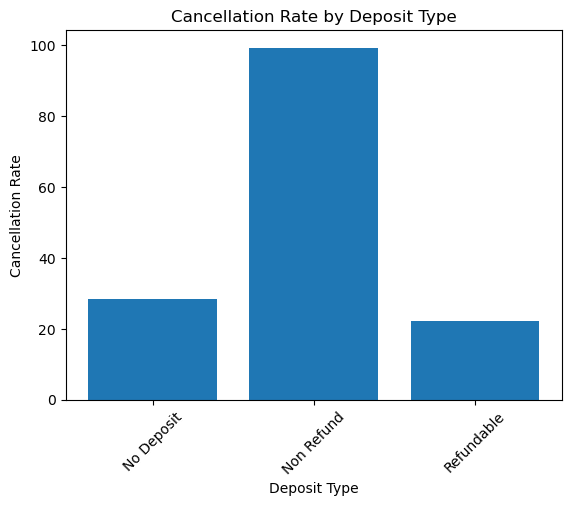

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv"

# Load the latest version
df = pd.read_csv(URL)

print("------------------------------------------------------------------")
print("Data Elements")
print()
print(df.info())
print()

print("------------------------------------------------------------------")
print("Five Five Rows")
print()
print(df.head())
print()

print("------------------------------------------------------------------")
print("Missing Data")
print()
print(df.isnull().sum())
print()

# Remove columns and missing data.
drop_columns = ['name', 'email', 'phone-number', 'credit_card', 'agent', 'company']
df.drop(drop_columns, axis=1, inplace=True)
df.dropna(inplace=True)

# Change reservation_status_date to date/time
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

print("------------------------------------------------------------------")
print("Statistical Description of Numerical Data")
print()
print(df.describe())
print()

print("------------------------------------------------------------------")
print("Statistical Description of Object Data")
print()
print(df.describe(include='object'))
print()

print("------------------------------------------------------------------")
# outlier detection for lead_time, adults, children, babies, adr
sns.boxplot(x=df['lead_time'], color='blue')
plt.title('Lead Time with Outliers')
plt.xlabel('Lead Time')
plt.show()

sns.boxplot(x=df['adults'], color='blue')
plt.title('Number of Adults with Outliers')
plt.xlabel('Number of Adults')
plt.show()

sns.boxplot(x=df['children'], color='blue')
plt.title('Number of Children with Outliers')
plt.xlabel('Number of Children')
plt.show()

sns.boxplot(x=df['babies'], color='blue')
plt.title('Number of Babies with Outliers')
plt.xlabel('Number of Babies')
plt.show()

sns.boxplot(x=df['adr'], color='blue')
plt.title('Average Daily Rate with Outliers')
plt.xlabel('Average Daily Rate')
plt.show()

#remove outlier from average daily rate.
df = df[df['adr'] < 5000]

print("------------------------------------------------------------------")
print()

print("Hotel Category")
print()
df['hotel'].value_counts().plot(kind='bar')
plt.title("Number of Reservation per Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=45)
plt.show()

print("Cancelled")
print()
cancel_map = {0: 'Not Cancelled', 1: 'Cancelled'}
df['cancel_labeled'] = df['is_canceled'].map(cancel_map)
df['cancel_labeled'].value_counts().plot(kind='bar')
plt.title("Cancellations")
plt.xlabel("Cancelled")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.show()

print("------------------------------------------------------------------")
print()
print("Cancellations by Hotel Type")
print()

grouped = df.groupby(['hotel', 'cancel_labeled']).size().unstack()
grouped.plot(kind='bar')
plt.title('Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.show()


correlation = df['lead_time'].corr(df['is_canceled'])
print("------------------------------------------------------------------")
print()
print(f"The correlation between lead_time and is_canceled: {correlation:.4f}")
print("This indicated a small positive correlation.")

correlation = df['adr'].corr(df['is_canceled'])
print("------------------------------------------------------------------")
print()
print(f"The correlation between adr and is_canceled: {correlation:.4f}")
print("This indicated a very small positive correlation.")

correlation = df['booking_changes'].corr(df['is_canceled'])
print("------------------------------------------------------------------")
print()
print(f"The correlation between booking_changes and is_canceled: {correlation:.4f}")
print("This indicated a small negative correlation.")

correlation = df['total_of_special_requests'].corr(df['is_canceled'])
print("------------------------------------------------------------------")
print()
print(f"The correlation between total_of_special_requests and is_canceled: {correlation:.4f}")
print("This indicated a small negative correlation.")

#Cancellation rates by market segment
cancellation_stats = df.groupby('market_segment')['is_canceled'].agg(
    total_bookings='count',
    total_canceled='sum'
).reset_index()
cancellation_stats['cancellation_rate'] = cancellation_stats['total_canceled'] / cancellation_stats['total_bookings'] * 100

print("------------------------------------------------------------------")
print()
print("Cancellation Rates by Market Segment")
print(cancellation_stats)

segments = cancellation_stats['market_segment']
rates = cancellation_stats['cancellation_rate']

# Plot
plt.bar(segments, rates)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

#Cancellation rates by deposit
cancellation_stats = df.groupby('deposit_type')['is_canceled'].agg(
    total_bookings='count',
    total_canceled='sum'
).reset_index()
cancellation_stats['cancellation_rate'] = cancellation_stats['total_canceled'] / cancellation_stats['total_bookings'] * 100

print("------------------------------------------------------------------")
print()
print("Cancellation Rates by Deposit Type")
print(cancellation_stats)

deposit = cancellation_stats['deposit_type']
rates = cancellation_stats['cancellation_rate']

# Plot
plt.bar(deposit, rates)
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

In [67]:
#Naive Bayes (multinomial) algorithm to predict cancellations

import os
import urllib.request

os.environ['PYSPARK_PYTHON'] = 'C:\\ProgramData\\Anaconda3\\envs\\pyspark310\\python.exe'

from pyspark.sql import SparkSession
from pyspark.sql.functions import when
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder \
        .appName('CSV Loader') \
        .getOrCreate()

url = 'https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv'
filename = 'hotel_booking.csv'

urllib.request.urlretrieve(url,filename)

df = spark.read.csv('hotel_booking.csv', header=True, inferSchema=True)

features = [
    'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations',
    'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests',
    'deposit_type', 'customer_type'
]
df = df.select(*features, 'is_canceled')
adr_mean = df.selectExpr("percentile_approx(adr, 0.5)").first()[0]
df = df.withColumn("adr", when(df["adr"] < 0, adr_mean).otherwise(df["adr"]))
df.dropna()

deposit_indexer = StringIndexer(inputCol='deposit_type', outputCol='deposit_type_index')
customer_indexer = StringIndexer(inputCol='customer_type', outputCol='customer_type_index')

#create vector
assembler = VectorAssembler(
    inputCols=[
        'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations',
        'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests',
        'deposit_type_index', 'customer_type_index'
    ],
    outputCol='features'
)

df = df.withColumnRenamed('is_canceled', 'label')

pipeline = Pipeline(stages=[deposit_indexer, customer_indexer, assembler])

assembled_df = pipeline.fit(df).transform(df).select('features', 'label')

#Split data into training and test
train_data, test_data = assembled_df.randomSplit([0.8,0.2], seed=123)

#Train Naive Bayes
nb = NaiveBayes(modelType='multinomial', featuresCol='features', labelCol='label')
model = nb.fit(train_data)

#Predictions
predictions = model.transform(test_data)

#Evaluate model
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')

accuracy = evaluator.evaluate(predictions) * 100

print(f"Accuracy: {accuracy:.2f}%")
print()
confusion_df = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
confusion_df.show()

Accuracy: 64.48%

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|10545|
|    0|       1.0| 4348|
|    1|       0.0| 4060|
|    1|       1.0| 4718|
+-----+----------+-----+



In [68]:
#Naive Bayes (gaussian) algorithm to predict cancellations

import os
import urllib.request

os.environ['PYSPARK_PYTHON'] = 'C:\\ProgramData\\Anaconda3\\envs\\pyspark310\\python.exe'

from pyspark.sql import SparkSession
from pyspark.sql.functions import when
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder \
        .appName('CSV Loader') \
        .getOrCreate()

url = 'https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv'
filename = 'hotel_booking.csv'

urllib.request.urlretrieve(url,filename)

df = spark.read.csv('hotel_booking.csv', header=True, inferSchema=True)

features = [
    'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations',
    'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests',
    'deposit_type', 'customer_type'
]
df = df.select(*features, 'is_canceled')
#adr_mean = df.selectExpr("percentile_approx(adr, 0.5)").first()[0]
#df = df.withColumn("adr", when(df["adr"] < 0, adr_mean).otherwise(df["adr"]))
df.dropna()

deposit_indexer = StringIndexer(inputCol='deposit_type', outputCol='deposit_type_index')
customer_indexer = StringIndexer(inputCol='customer_type', outputCol='customer_type_index')

#create vector
assembler = VectorAssembler(
    inputCols=[
        'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations',
        'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests',
        'deposit_type_index', 'customer_type_index'
    ],
    outputCol='features'
)

df = df.withColumnRenamed('is_canceled', 'label')

pipeline = Pipeline(stages=[deposit_indexer, customer_indexer, assembler])

assembled_df = pipeline.fit(df).transform(df).select('features', 'label')

#Split data into training and test
train_data, test_data = assembled_df.randomSplit([0.8,0.2], seed=123)

#Train Naive Bayes
nb = NaiveBayes(modelType='gaussian', featuresCol='features', labelCol='label')
model = nb.fit(train_data)

#Predictions
predictions = model.transform(test_data)

#Evaluate model
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')

accuracy = evaluator.evaluate(predictions) * 100

print(f"Accuracy: {accuracy:.2f}%")
print()
confusion_df = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
confusion_df.show()

Accuracy: 55.92%

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 5322|
|    0|       1.0| 9571|
|    1|       0.0|  864|
|    1|       1.0| 7914|
+-----+----------+-----+



In [64]:
# Randon Forest without fine tuning
import os
import urllib.request

os.environ['PYSPARK_PYTHON'] = 'C:\\ProgramData\\Anaconda3\\envs\\pyspark310\\python.exe'

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder \
        .appName('CSV Loader') \
        .getOrCreate()

url = 'https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv'
filename = 'hotel_booking.csv'

urllib.request.urlretrieve(url,filename)

df = spark.read.csv('hotel_booking.csv', header=True, inferSchema=True)

#Random Forrest Classifier Model to see if accuracy improves

from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

# Select features for the Random Forest model
selected_cols = [
    'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes',
    'required_car_parking_spaces', 'total_of_special_requests', 'deposit_type', 'customer_type'
]

rf = df.select(*selected_cols, 'is_canceled')
rf.dropna()

deposit_indexer = StringIndexer(inputCol='deposit_type', outputCol='deposit_type_index')
customer_indexer = StringIndexer(inputCol='customer_type', outputCol='customer_type_index')

assembler = VectorAssembler(
    inputCols=[
        'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes',
        'required_car_parking_spaces', 'total_of_special_requests', 'deposit_type_index', 'customer_type_index'
    ],
    outputCol='features'
)

rf = rf.withColumnRenamed('is_canceled', 'label')

pipeline = Pipeline(stages=[deposit_indexer, customer_indexer, assembler])

prepared_data = pipeline.fit(rf).transform(rf).select('features', 'label')

train_data, test_data = prepared_data.randomSplit([0.8, 0.2], seed=42)

rf_classifier = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100)
rf_model = rf_classifier.fit(train_data)

predictions = rf_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions) * 100

print(f"Random Forest Accuracy: {accuracy:.2f}%")
print()
confusion_df = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
confusion_df.show()

Random Forest Accuracy: 77.08%

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|15015|
|    0|       1.0|   39|
|    1|       0.0| 5417|
|    1|       1.0| 3329|
+-----+----------+-----+



In [63]:
# Random Forest with fine tuning

import os
import urllib.request

os.environ['PYSPARK_PYTHON'] = 'C:\\ProgramData\\Anaconda3\\envs\\pyspark310\\python.exe'

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder \
        .appName('CSV Loader') \
        .getOrCreate()

url = 'https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv'
filename = 'hotel_booking.csv'

urllib.request.urlretrieve(url,filename)

df = spark.read.csv('hotel_booking.csv', header=True, inferSchema=True)

#Random Forrest Classifier Model to see if accuracy improves

from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

# Select features for the Random Forest model
selected_cols = [
    'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes',
    'required_car_parking_spaces', 'total_of_special_requests', 'deposit_type', 'customer_type'
]

rf = df.select(*selected_cols, 'is_canceled')
rf.dropna()

deposit_indexer = StringIndexer(inputCol='deposit_type', outputCol='deposit_type_index')
customer_indexer = StringIndexer(inputCol='customer_type', outputCol='customer_type_index')

assembler = VectorAssembler(
    inputCols=[
        'lead_time', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes',
        'required_car_parking_spaces', 'total_of_special_requests', 'deposit_type_index', 'customer_type_index'
    ],
    outputCol='features'
)

rf = rf.withColumnRenamed('is_canceled', 'label')

pipeline = Pipeline(stages=[deposit_indexer, customer_indexer, assembler])

prepared_data = pipeline.fit(rf).transform(rf).select('features', 'label')

train_data, test_data = prepared_data.randomSplit([0.8, 0.2], seed=42)

rf_classifier = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100, maxDepth=15, maxBins=96)
rf_model = rf_classifier.fit(train_data)

predictions = rf_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions) * 100

print(f"Random Forest Accuracy: {accuracy:.2f}%")
print()
confusion_df = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
confusion_df.show()


Random Forest Accuracy: 80.82%

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|14160|
|    0|       1.0|  894|
|    1|       0.0| 3672|
|    1|       1.0| 5074|
+-----+----------+-----+

